# Activation Functions in Neural Networks

Activation functions introduce **non-linearity** into a neural network. Without them every layer is just a linear transformation, and stacking linear layers is equivalent to having a single linear layer — no matter how deep the network is.

This notebook answers three questions:
1. **What** do common activation functions look like?
2. **Why** does a linear model fail on non-linearly separable data?
3. **How** does adding a non-linear activation enable an MLP to solve the problem?

---
**Dataset used:** `make_circles` — two concentric rings that no straight line can separate.

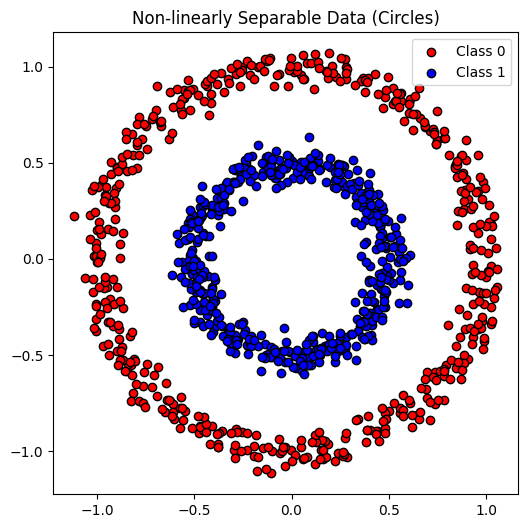

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

plt.figure(figsize=(6, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Class 0', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class 1', edgecolors='k')
plt.legend()
plt.title('Non-linearly Separable Data (Circles)')
plt.show()


## Defining Common Activation Functions

Below we implement and plot four widely-used activation functions. Each introduces non-linearity differently, with trade-offs around gradient flow and output range:

| Function | Output range | Key property |
|---|---|---|
| Sigmoid | (0, 1) | Smooth, saturates at extremes |
| Tanh | (-1, 1) | Zero-centered, stronger gradients |
| ReLU | [0, ∞) | Fast, sparse, can "die" |
| Leaky ReLU | (-∞, ∞) | Fixes the dying-ReLU problem |

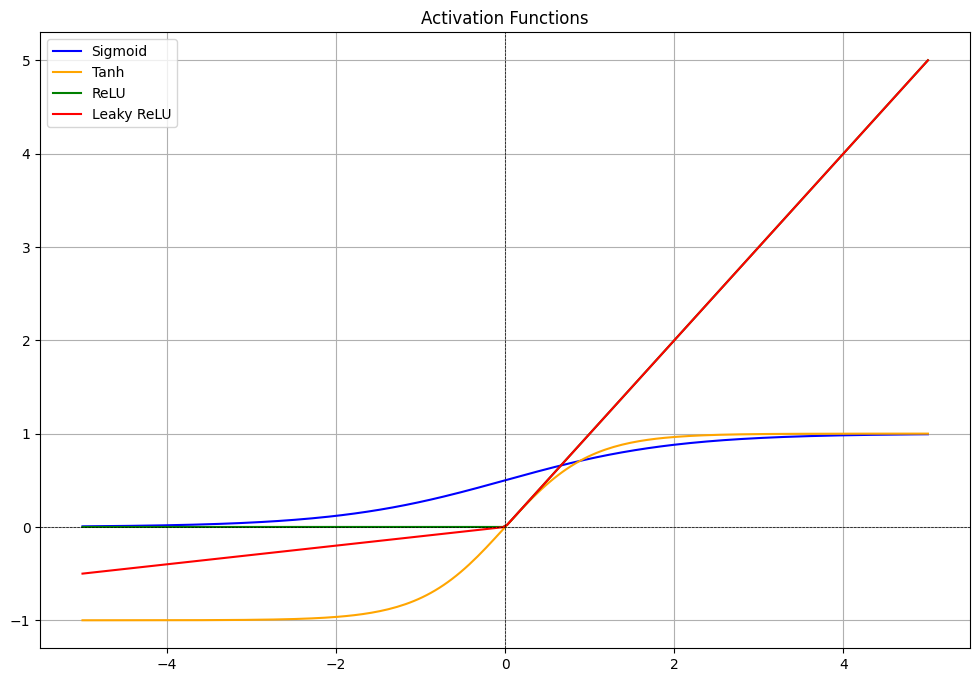

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)

z = np.linspace(-5, 5, 200)

plt.figure(figsize=(12, 8))
plt.plot(z, sigmoid(z), label='Sigmoid', color='blue')
plt.plot(z, tanh(z), label='Tanh', color='orange')
plt.plot(z, relu(z), label='ReLU', color='green')
plt.plot(z, leaky_relu(z), label='Leaky ReLU', color='red')
plt.title('Activation Functions')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.legend()
plt.grid(True)
plt.show()


## Why a Linear Transformation Alone Fails

Without an activation function a neural network is just a linear model, regardless of how many layers it has. The plot below projects the circle data onto a single axis using `z = Wx + b`. The result: the two classes completely overlap and cannot be separated.

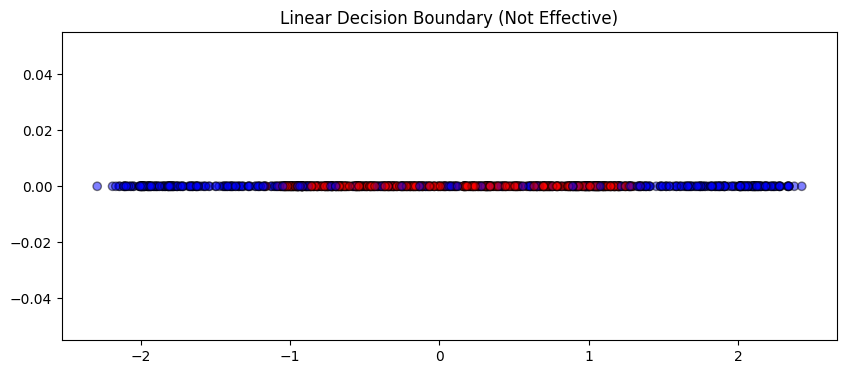

In [6]:
W = np.array([1.5, -1.5])
b = 0.1

z_linear = np.dot(X, W) + b

plt.figure(figsize=(10, 4))
plt.scatter(z_linear, np.zeros_like(z_linear), c=y, cmap='bwr', edgecolors='k', alpha=0.5)
plt.title('Linear Decision Boundary (Not Effective)')
plt.show()

## Activation Functions in Action

Applying a non-linear activation to the same linear output `z` transforms the data in ways that can help separate the classes. Compare how **Sigmoid** (squashes to 0–1) and **ReLU** (kills negatives) reshape the distribution of the two circle classes.

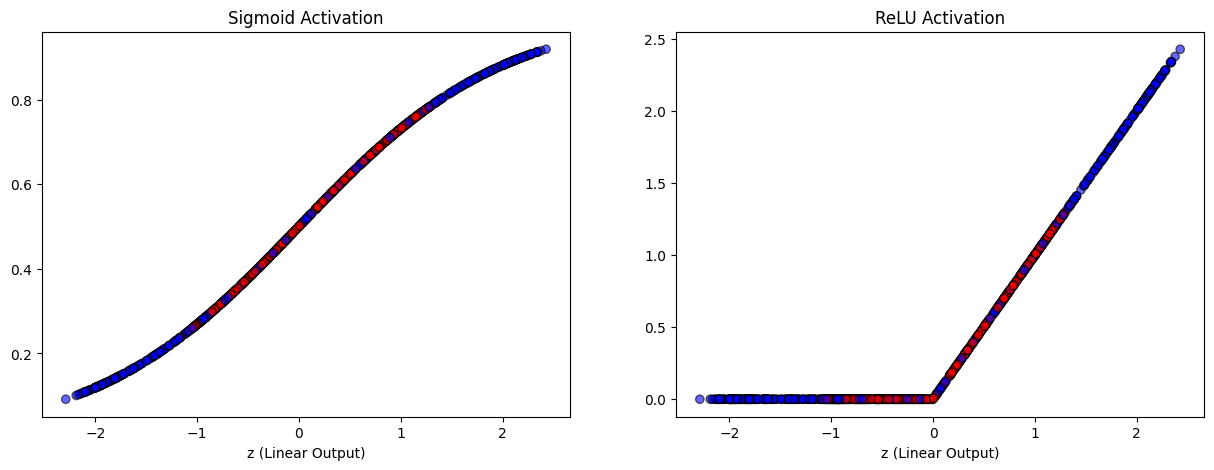

In [7]:
a_sigmoid = sigmoid(z_linear)
e_relu = relu(z_linear)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.scatter(z_linear, a_sigmoid, c=y, cmap='bwr', edgecolors='k', alpha=0.6)
ax1.set_title('Sigmoid Activation')
ax1.set_xlabel('z (Linear Output)')

ax2.scatter(z_linear, e_relu, c=y, cmap='bwr', edgecolors='k', alpha=0.6)
ax2.set_title('ReLU Activation')
ax2.set_xlabel('z (Linear Output)')
plt.show()

## Putting It Together: MLP with a Non-Linear Activation

A single linear transformation cannot separate the two circles — but a **Multi-Layer Perceptron** with a non-linear activation can learn a curved decision boundary.

Below we train an MLP with one hidden layer (10 ReLU neurons) using sklearn and visualize the learned boundary.

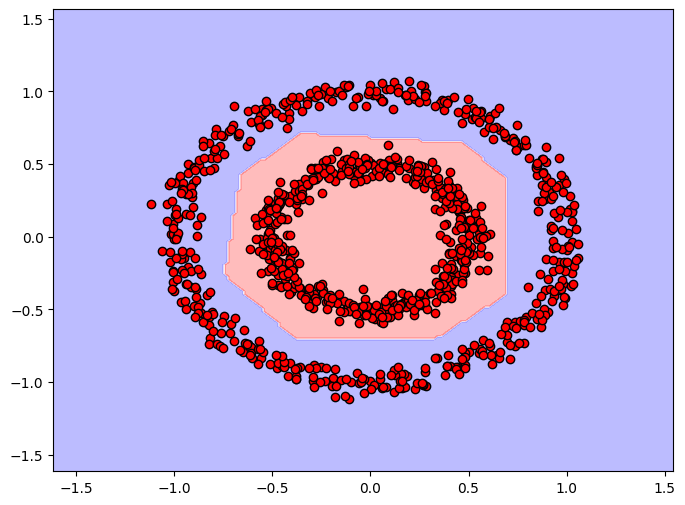

In [16]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=1000, random_state=42, solver='adam')
model.fit(X, y)

h=0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c='red', label='Class 0', edgecolors='k')
plt.show()

- You can see that the MLPClassifier with ReLU activation can learn a non-linear decision boundary to separate the two classes effectively, while a linear model would fail to do so.

- Please play with the max iteration and the number of hidden layer neurons to see how it affects the decision boundary and the model's performance.